In [1]:
'''Sketch the result of applying the hit-or-miss transform to the image and structuring
element shown. Indicate clearly the origin and border you selected for
the structuring element.'''
import numpy as np
import cv2
import matplotlib.pyplot as plt
img=cv2.imread(r'E:\BG\utk.tif',0)
threshold=128
binary_img=(img>threshold).astype(np.uint8)*255

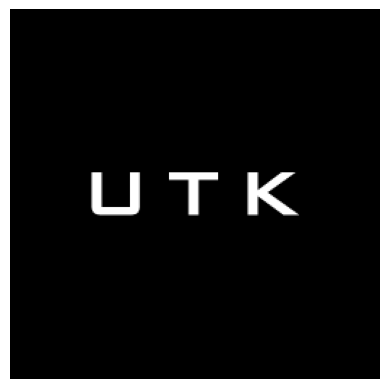

In [2]:
plt.imshow(img,cmap='gray')
plt.axis('off')
plt.show()

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


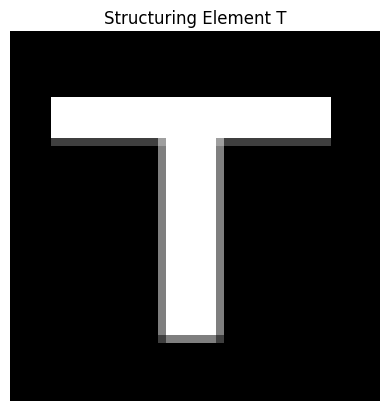

In [6]:
#creating structuring element T
def crop(img,r_start,r_end,c_start,c_end):
    rows=r_end-r_start
    cols=c_end-c_start
    cropped=np.zeros((rows,cols),dtype=np.uint8)
    for i in range(rows):
        for j in range(cols):
            cropped[i,j]=img[r_start+i,c_start+j]
    return cropped
t_cropped=crop(img,105,150,105,150)
print(t_cropped)
plt.title('Structuring Element T')
plt.imshow(t_cropped,cmap='gray')
plt.axis('off')
plt.show()


In [7]:
binary_crop=(t_cropped>127).astype(np.uint8)
h,w=binary_crop.shape
thin_T=np.zeros_like(binary_crop)
center_col=w//2
thin_T[:,center_col]=binary_crop[:,center_col]
top_row=np.argmax(np.sum(binary_crop, axis=1)>0)  # first row with pixels
thin_T[top_row,:]=binary_crop[top_row, :]

small_T=thin_T[::h//5, ::w//5]
small_T=small_T[:5, :5]

small_T=(small_T>0).astype(np.uint8)


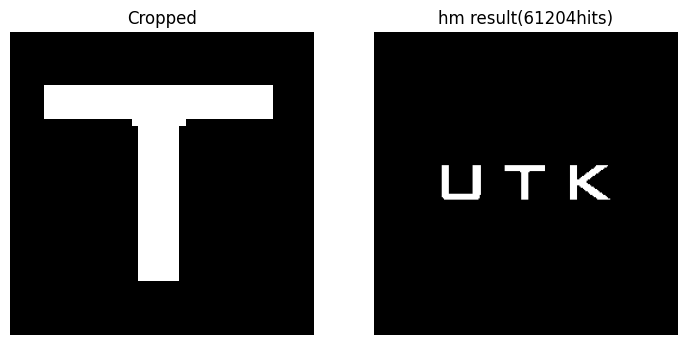

In [12]:
B=(small_T==1).astype(np.uint8)
C=(small_T==0).astype(np.uint8)
h,w=binary_img.shape
result=np.zeros_like(binary_img)
for i in range(2,h-2):
    for j in range(2,w-2):
        patch=binary_img[i-2:i+3,j-2:j+3]
        if np.all(patch[B==1]==1)and np.all(patch[C==1]==0):
            result[i,j]=1
            
plt.figure(figsize=(18,10))
plt.subplot(1,4,1)
plt.title("Cropped")
plt.imshow(binary_crop,cmap='gray')
plt.axis('off')
plt.subplot(1,4,2)
plt.title(f"hm result({np.sum(result)}hits)")
plt.imshow(binary_img,cmap='gray')
plt.axis('off')
plt.show()